# 3.5 导读与数学基础：Transformer 序列推荐

> 阅读版与 Web 应用内容一致；实验数值来自本 Notebook 的已执行输出。

## Goal

理解行为序列、位置编码、Scaled Dot-Product Attention、因果遮罩和下一物品预测，并比较 SASRec、BERT4Rec 与 HSTU 的任务边界。

## Setup

默认 `smoke` 档使用仓库内固定版本的 GroupLens **MovieLens latest-small** 真实行为子集，CPU 可重复执行；`full` 档只扩大真实数据规模与训练配置，不切换到合成数据。数据包含真实匿名用户、电影、评分和时间戳；实验只做确定性截取与任务重构，不随机制造交互、标签或行为序列。原始许可与引用保存在 `data/ml-latest-small/README.txt`。

**主要资料：** [SASRec](https://arxiv.org/abs/1808.09781) · [SASRec 官方实现](https://github.com/kang205/SASRec) · [BERT4Rec](https://arxiv.org/abs/1904.06690) · [HSTU](https://arxiv.org/abs/2402.17152)

In [1]:
from pathlib import Path
import os, sys, json
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
os.environ.setdefault("RECSYS_PROFILE", "smoke")
PROFILE = os.environ["RECSYS_PROFILE"]
from recsys_lab.data import load_movielens, movielens_provenance
real_ratings, real_movies = load_movielens()
REAL_DATASET = movielens_provenance(real_ratings)
print({"profile": PROFILE, "root": str(ROOT), "real_dataset": REAL_DATASET})
assert REAL_DATASET["randomly_fabricated_rows"] == 0

/usr/local/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{'profile': 'smoke', 'root': '/workspace', 'real_dataset': {'dataset': 'MovieLens latest-small (GroupLens, generated 2018-09-26)', 'source': 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip', 'license_file': '/workspace/data/ml-latest-small/README.txt', 'rows_used': 26732, 'users_used': 120, 'items_used': 600, 'time_min_utc': '1996-10-17T11:51:49+00:00', 'time_max_utc': '2018-09-13T21:38:16+00:00', 'positive_rule': 'like := observed rating >= 4.0; very_like := observed rating >= 4.5', 'randomly_fabricated_rows': 0}}


## 如何使用本导读

先阅读布局和论文问题，再运行共同数学演示。完成 Checks 后进入独立算法 Notebook；各算法会重新给出本模型的公式和更小的 Python 演示，不要求记住本页所有公式。

## 本章布局与选型地图

| 方法 | 可见上下文 | 训练目标 | 适用位置 |
|---|---|---|---|
| GRU4Rec | 过去 | next-item | 短序列、递推基线 |
| SASRec | 过去（causal mask） | 正负 next-item | 通用序列召回/排序 |
| BERT4Rec | 左右上下文 | masked item | 离线表征与补全式预训练 |
| HSTU | 过去、推荐特化 attention | next-item | 超长行为流与生成式推荐 |
| 3.5.1 实战 | MovieLens 真实时间序列 | pairwise loss | Torch-RecHub SASRec |
| 3.5 总结 | SASRec 与热门基线结果 | HR@10 | 效果—成本判断 |

SASRec 是理解 Transformer 推荐的最佳起点：结构足够完整，又保留明确的 next-item 任务。BERT4Rec 改成双向 masked-item 训练；HSTU 则进一步针对工业推荐行为流和系统吞吐重构。

## 来源论文解读

- **SASRec (ICDM 2018)** 在每个时刻自适应选择相关历史，用因果自注意力兼顾 Markov 式近期信号和较长依赖。
- **BERT4Rec (CIKM 2019)** 使用双向 Transformer 与 Cloze 任务；它更充分利用上下文，但训练目标与在线 next-item 推理存在差异。
- **HSTU (2024)** 不只是加深 Transformer，而是围绕高基数、非平稳推荐序列重新设计 attention 和系统实现。

这些模型都要求严格时间协议。把测试物品放进历史、先用全量数据建词表，或随机打乱序列，都会造成未来信息泄漏。

## 共同数学：位置、注意力与因果遮罩

item embedding 本身不知道顺序，因此输入为 $x_t=e(i_t)+p_t$。投影得到 $Q=XW_Q$、$K=XW_K$、$V=XW_V$，注意力为

$$\mathrm{Attention}(Q,K,V)=\mathrm{softmax}\left(\frac{QK^\top}{\sqrt{d_k}}+M\right)V$$

SASRec 的因果 mask $M_{t,j}=-\infty$（当 $j>t$），确保预测位置 $t$ 看不到未来。缩放因子 $\sqrt{d_k}$ 防止维度较大时点积过大、Softmax 过早饱和。多头注意力让不同子空间分别关注近期转移、类型偏好等模式。

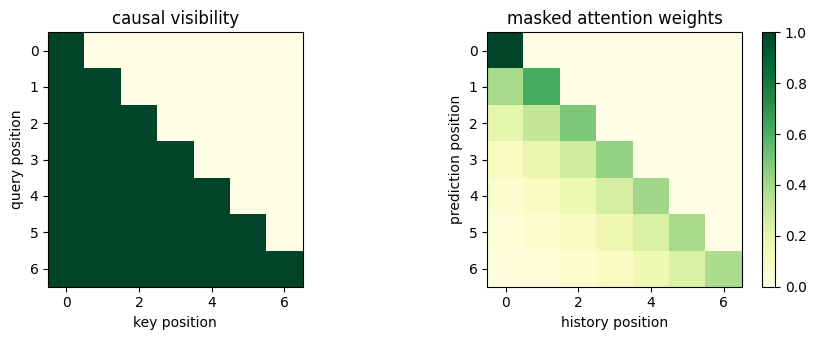

{'shape': (7, 7), 'row_sums': [1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0], 'future_weight': 0.0}


In [2]:
import numpy as np, matplotlib.pyplot as plt
length=7; raw=np.fromfunction(lambda row,col: 2.2-.45*np.abs(row-col),(length,length)); raw[np.triu(np.ones((length,length),dtype=bool),1)]=-np.inf
weights=np.exp(raw-np.max(raw,axis=1,keepdims=True)); weights/=weights.sum(1,keepdims=True)
fig,axes=plt.subplots(1,2,figsize=(9,3.5)); axes[0].imshow(np.tril(np.ones((length,length))),cmap='YlGn'); axes[0].set(title='causal visibility',xlabel='key position',ylabel='query position')
image=axes[1].imshow(weights,cmap='YlGn'); axes[1].set(title='masked attention weights',xlabel='history position',ylabel='prediction position'); plt.colorbar(image,ax=axes[1]); plt.tight_layout(); plt.show()
print({'shape':weights.shape,'row_sums':weights.sum(1).round(3).tolist(),'future_weight':float(weights[np.triu_indices(length,1)].sum())})

## 学习顺序

1. 说清业务阶段和输入输出；2. 手算共享数学；3. 进入每个独立算法；4. 执行训练与推理；5. 最后打开章节总结读取实际结果。

## Checks

In [3]:
assert weights.shape==(length,length)
assert np.allclose(weights.sum(1),1)
assert weights[np.triu_indices(length,1)].sum()==0
print('PASS：注意力按行归一化，因果遮罩使未来权重严格为 0。')

PASS：注意力按行归一化，因果遮罩使未来权重严格为 0。


## Next Steps

从左侧 Notebook 导航进入本章第一个算法。遇到公式时依次检查：符号代表什么、数组形状是什么、用小数字怎么算、代码输出是否符合直觉。